## 0 - Load log cluster time series

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

CLUSTER_TIMESERIES_PATH = Path(
    "../data/processed/log_cluster_timeseries.csv"
)

CLUSTERED_LOGS_PATH = Path(
    "../data/processed/clustered_logs.csv"
)

TIMESERIES_REQUIRED_COLUMNS = {
    "time_window",
    "service_key",
    "analysis_group",
    "log_count",
    "info_count",
    "warn_count",
    "error_count",
    "unique_template_count",
    "unique_reporter_count",
    "error_ratio",
    "warn_ratio",
}

LOGS_REQUIRED_COLUMNS = {
    "LineId",
    "timestamp",
    "time_window",
    "Level",
    "LoggingReporter",
    "Content",
    "EventId",
    "EventTemplate",
    "service_key",
    "analysis_group",
}

cluster_timeseries_df = pd.read_csv(
    CLUSTER_TIMESERIES_PATH,
)

clustered_logs_df = pd.read_csv(
    CLUSTERED_LOGS_PATH,
    low_memory=False,
)

cluster_timeseries_df["time_window"] = (
    pd.to_datetime(
        cluster_timeseries_df["time_window"],
        format="mixed",
        utc=True,
    )
)

for column in ["timestamp", "time_window"]:
    clustered_logs_df[column] = pd.to_datetime(
        clustered_logs_df[column],
        format="mixed",
        utc=True,
    )

missing_timeseries_columns = (
    TIMESERIES_REQUIRED_COLUMNS
    - set(cluster_timeseries_df.columns)
)

missing_log_columns = (
    LOGS_REQUIRED_COLUMNS
    - set(clustered_logs_df.columns)
)

assert not missing_timeseries_columns, (
    "Missing time-series columns: "
    f"{sorted(missing_timeseries_columns)}"
)

assert not missing_log_columns, (
    "Missing clustered-log columns: "
    f"{sorted(missing_log_columns)}"
)

cluster_timeseries_df = (
    cluster_timeseries_df
    .sort_values(
        ["time_window", "service_key", "analysis_group"]
    )
    .reset_index(drop=True)
)

clustered_logs_df = (
    clustered_logs_df
    .sort_values(["timestamp", "LineId"])
    .reset_index(drop=True)
)

print("Loaded:", CLUSTER_TIMESERIES_PATH.resolve())
print("Time-series shape:", cluster_timeseries_df.shape)
print("Loaded:", CLUSTERED_LOGS_PATH.resolve())
print("Clustered logs shape:", clustered_logs_df.shape)

display(cluster_timeseries_df.head())
display(clustered_logs_df.head())

Loaded: E:\AIO\Project\aiops-trainticket-pipeline\data\processed\log_cluster_timeseries.csv
Time-series shape: (11039, 11)
Loaded: E:\AIO\Project\aiops-trainticket-pipeline\data\processed\clustered_logs.csv
Clustered logs shape: (147205, 23)


,time_window,service_key,analysis_group,log_count,info_count,warn_count,error_count,unique_template_count,unique_reporter_count,error_ratio,warn_ratio
0,2022-06-14 09:26:30+00:00,train-ticket/ts-auth-service,semantic_cluster_0,1,1,0,0,1,1,0.0,0.0
1,2022-06-14 09:26:30+00:00,train-ticket/ts-auth-service,semantic_cluster_12,2,1,1,0,2,2,0.0,0.5
2,2022-06-14 09:29:00+00:00,train-ticket/ts-auth-service,semantic_cluster_0,1,1,0,0,1,1,0.0,0.0
3,2022-06-14 09:29:00+00:00,train-ticket/ts-auth-service,semantic_cluster_11,1,1,0,0,1,1,0.0,0.0
4,2022-06-14 09:29:00+00:00,train-ticket/ts-auth-service,semantic_cluster_24,1,1,0,0,1,1,0.0,0.0


,LineId,Date,Time,Level,Number,LoggingReporter,Content,EventId,EventTemplate,ParameterList,...,service_namespace,service_name,service_key,is_info,is_warn,is_error,is_clusterable,semantic_cluster_id,analysis_group,time_window
0,147205,2022-06-14,17:26:35.024,INFO,1,[io-15678-exec-6] v.controller.VerifyCodeCont...,Image code,e1c753fb,Image code,[],...,train-ticket,ts-auth-service,train-ticket/ts-auth-service,1,0,0,True,12.0,semantic_cluster_12,2022-06-14 09:26:30+00:00
1,147204,2022-06-14,17:26:35.028,WARN,1,[io-15678-exec-6] v.service.impl.VerifyCodeSe...,"Get image code warn.Cookie not found,Path Info...",13095a7c,"Get image code warn.Cookie not found,Path Info...",[],...,train-ticket,ts-auth-service,train-ticket/ts-auth-service,0,1,0,True,12.0,semantic_cluster_12,2022-06-14 09:26:30+00:00
2,147203,2022-06-14,17:26:35.032,INFO,1,[io-15678-exec-6] v.service.impl.VerifyCodeSe...,9QOY ___ st,db7d54fd,<*> ___ st,['9QOY'],...,train-ticket,ts-auth-service,train-ticket/ts-auth-service,1,0,0,True,0.0,semantic_cluster_0,2022-06-14 09:26:30+00:00
3,147201,2022-06-14,17:29:06.952,INFO,1,[io-12340-exec-6] auth.controller.UserControl...,Login request of username: admin,fa7a3678,Login request of username: <*>,['admin'],...,train-ticket,ts-auth-service,train-ticket/ts-auth-service,1,0,0,True,0.0,semantic_cluster_0,2022-06-14 09:29:00+00:00
4,147202,2022-06-14,17:29:06.952,INFO,1,[io-12340-exec-6] auth.security.UserDetailsSe...,UsernamePasswordAuthenticationToken username ...,12b853f4,UsernamePasswordAuthenticationToken username <*>,[':admin'],...,train-ticket,ts-auth-service,train-ticket/ts-auth-service,1,0,0,True,11.0,semantic_cluster_11,2022-06-14 09:29:00+00:00


## 1 - Xác định active period

In [2]:
TIME_BUCKET = "30s"
ACTIVE_GAP = pd.Timedelta("5min")

service_activity_df = (
    cluster_timeseries_df[
        ["service_key", "time_window"]
    ]
    .drop_duplicates()
    .sort_values(
        ["service_key", "time_window"]
    )
    .reset_index(drop=True)
)

service_activity_df["gap"] = (
    service_activity_df
    .groupby("service_key")["time_window"]
    .diff()
)

service_activity_df["new_active_period"] = (
    service_activity_df["gap"].isna()
    | (service_activity_df["gap"] > ACTIVE_GAP)
)

service_activity_df["active_period_id"] = (
    service_activity_df
    .groupby("service_key")[
        "new_active_period"
    ]
    .cumsum()
    .astype("int32")
)

active_periods_df = (
    service_activity_df
    .groupby(
        ["service_key", "active_period_id"],
        as_index=False,
    )
    .agg(
        period_start=("time_window", "min"),
        period_end=("time_window", "max"),
        observed_buckets=("time_window", "size"),
    )
)

active_periods_df["duration_minutes"] = (
    (
        active_periods_df["period_end"]
        - active_periods_df["period_start"]
    )
    .dt.total_seconds()
    .div(60)
)

display(active_periods_df)

,service_key,active_period_id,period_start,period_end,observed_buckets,duration_minutes
0,train-ticket/ts-auth-service,1,2022-06-14 09:26:30+00:00,2022-06-14 09:29:00+00:00,2,2.5
1,train-ticket/ts-auth-service,2,2022-06-14 09:37:30+00:00,2022-06-14 09:37:30+00:00,1,0.0
2,train-ticket/ts-auth-service,3,2022-06-14 09:48:00+00:00,2022-06-14 09:59:30+00:00,9,11.5
3,train-ticket/ts-auth-service,4,2022-06-14 10:07:00+00:00,2022-06-14 10:12:00+00:00,4,5.0
4,train-ticket/ts-auth-service,5,2022-06-14 10:20:00+00:00,2022-06-14 10:20:00+00:00,1,0.0
...,...,...,...,...,...,...
114,train-ticket/ts-auth-service,115,2022-07-13 09:27:00+00:00,2022-07-13 10:01:30+00:00,47,34.5
115,train-ticket/ts-auth-service,116,2022-07-13 10:09:00+00:00,2022-07-13 10:16:00+00:00,12,7.0
116,train-ticket/ts-auth-service,117,2022-07-13 10:43:00+00:00,2022-07-13 10:46:30+00:00,5,3.5
117,train-ticket/ts-auth-service,118,2022-07-13 10:59:00+00:00,2022-07-13 10:59:30+00:00,2,0.5


## 2 - Gắn active period vào dữ liệu aggregate

In [3]:
cluster_timeseries_with_period_df = (
    cluster_timeseries_df
    .merge(
        service_activity_df[
            [
                "service_key",
                "time_window",
                "active_period_id",
            ]
        ],
        on=["service_key", "time_window"],
        how="left",
        validate="many_to_one",
    )
)

assert (
    cluster_timeseries_with_period_df[
        "active_period_id"
    ]
    .notna()
    .all()
)

cluster_timeseries_with_period_df[
    "active_period_id"
] = (
    cluster_timeseries_with_period_df[
        "active_period_id"
    ]
    .astype("int32")
)

## 3 - Tạo timeline đầy đủ 30 giây

In [4]:
COUNT_COLUMNS = [
    "log_count",
    "info_count",
    "warn_count",
    "error_count",
    "unique_template_count",
    "unique_reporter_count",
]

completed_frames = []

period_group_columns = [
    "service_key",
    "active_period_id",
]

for period_keys, period_df in (
    cluster_timeseries_with_period_df
    .groupby(
        period_group_columns,
        dropna=False,
        sort=False,
    )
):
    (
        service_key,
        active_period_id,
    ) = period_keys

    full_timeline = pd.date_range(
        start=period_df["time_window"].min(),
        end=period_df["time_window"].max(),
        freq=TIME_BUCKET,
        tz="UTC",
    )

    active_groups = (
        period_df["analysis_group"]
        .dropna()
        .unique()
    )

    full_index = pd.MultiIndex.from_product(
        [full_timeline, active_groups],
        names=["time_window", "analysis_group"],
    )

    completed = (
        period_df
        .set_index(
            ["time_window", "analysis_group"]
        )
        .reindex(full_index)
        .reset_index()
    )

    completed["service_key"] = service_key
    completed["active_period_id"] = (
        active_period_id
    )

    completed[COUNT_COLUMNS] = (
        completed[COUNT_COLUMNS]
        .fillna(0)
        .astype("int64")
    )

    completed["error_ratio"] = (
        completed["error_count"]
        / completed["log_count"].clip(lower=1)
    )

    completed["warn_ratio"] = (
        completed["warn_count"]
        / completed["log_count"].clip(lower=1)
    )

    completed_frames.append(completed)

detection_input_df = (
    pd.concat(
        completed_frames,
        ignore_index=True,
    )
    .sort_values(
        [
            "service_key",
            "active_period_id",
            "analysis_group",
            "time_window",
        ]
    )
    .reset_index(drop=True)
)

print("Original rows:", len(cluster_timeseries_df))
print("Completed rows:", len(detection_input_df))

display(detection_input_df.head())

Original rows: 11039
Completed rows: 54612


,time_window,analysis_group,service_key,log_count,info_count,warn_count,error_count,unique_template_count,unique_reporter_count,error_ratio,warn_ratio,active_period_id
0,2022-06-14 09:26:30+00:00,semantic_cluster_0,train-ticket/ts-auth-service,1,1,0,0,1,1,0.0,0.0,1
1,2022-06-14 09:27:00+00:00,semantic_cluster_0,train-ticket/ts-auth-service,0,0,0,0,0,0,0.0,0.0,1
2,2022-06-14 09:27:30+00:00,semantic_cluster_0,train-ticket/ts-auth-service,0,0,0,0,0,0,0.0,0.0,1
3,2022-06-14 09:28:00+00:00,semantic_cluster_0,train-ticket/ts-auth-service,0,0,0,0,0,0,0.0,0.0,1
4,2022-06-14 09:28:30+00:00,semantic_cluster_0,train-ticket/ts-auth-service,0,0,0,0,0,0,0.0,0.0,1


### Visualize active periods and completed timeline

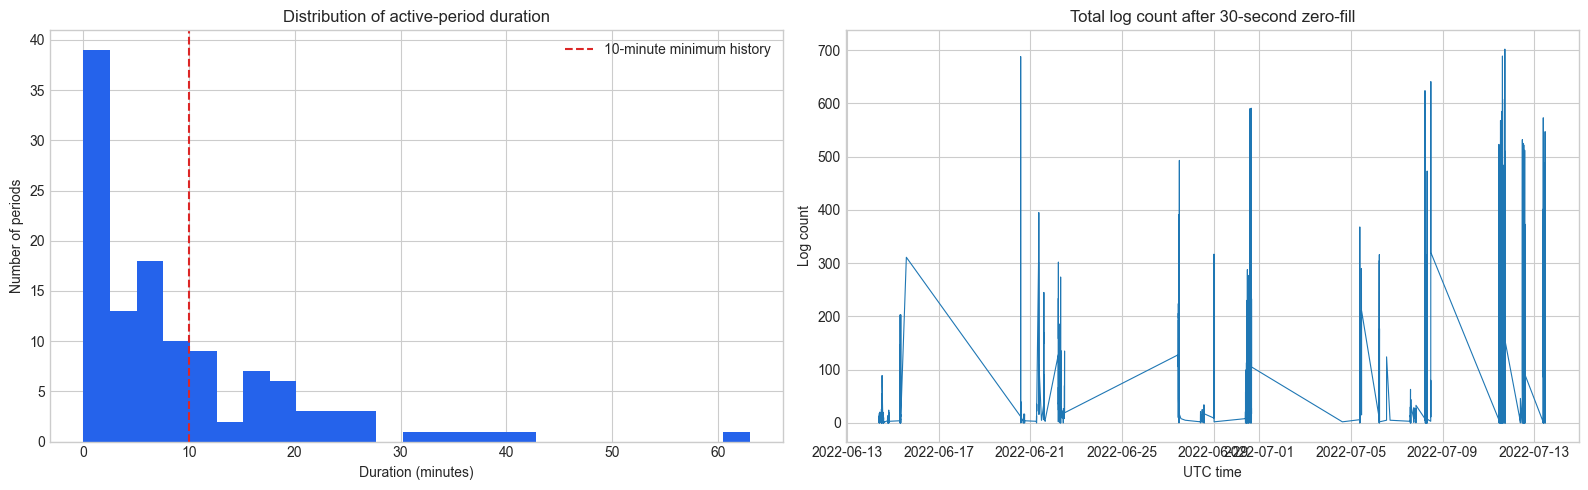

In [5]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

total_activity_df = (
    detection_input_df
    .groupby("time_window", as_index=False)
    .agg(log_count=("log_count", "sum"))
)

figure, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(active_periods_df["duration_minutes"], bins=25, color="#2563eb")
axes[0].axvline(10, color="#dc2626", linestyle="--", label="10-minute minimum history")
axes[0].set_title("Distribution of active-period duration")
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Number of periods")
axes[0].legend()

axes[1].plot(total_activity_df["time_window"], total_activity_df["log_count"], linewidth=0.8)
axes[1].set_title("Total log count after 30-second zero-fill")
axes[1].set_xlabel("UTC time")
axes[1].set_ylabel("Log count")
plt.tight_layout()
plt.show()

## 4 - Rolling Median + MAD

In [6]:
DETECTION_GROUPS = [
    "service_key",
    "active_period_id",
    "analysis_group",
]

ROLLING_WINDOW = 120   # 120 × 30 giây = 60 phút
MIN_HISTORY = 20      # ít nhất 10 phút lịch sử
ROBUST_Z_THRESHOLD = 6.0


def add_rolling_mad_features(
    frame,
    value_column,
):
    result = frame.copy()

    group_values = result.groupby(
        DETECTION_GROUPS,
        sort=False,
    )[value_column]

    result[f"{value_column}_history"] = (
        group_values.shift(1)
    )

    history_group = result.groupby(
        DETECTION_GROUPS,
        sort=False,
    )[f"{value_column}_history"]

    result[f"{value_column}_median"] = (
        history_group.transform(
            lambda series: (
                series
                .rolling(
                    ROLLING_WINDOW,
                    min_periods=MIN_HISTORY,
                )
                .median()
            )
        )
    )

    def rolling_mad(series):
        return (
            series
            .rolling(
                ROLLING_WINDOW,
                min_periods=MIN_HISTORY,
            )
            .apply(
                lambda values: np.median(
                    np.abs(
                        values
                        - np.median(values)
                    )
                ),
                raw=True,
            )
        )

    result[f"{value_column}_mad"] = (
        history_group.transform(rolling_mad)
    )

    deviation = (
        result[value_column]
        - result[f"{value_column}_median"]
    )

    mad = result[f"{value_column}_mad"]

    result[f"{value_column}_robust_z"] = (
        0.6745
        * deviation
        / mad.replace(0, np.nan)
    )

    # Trường hợp lịch sử luôn bằng 0 nên MAD = 0
    result[f"{value_column}_zero_baseline_spike"] = (
        result[f"{value_column}_median"].eq(0)
        & mad.eq(0)
        & result[value_column].gt(0)
    )

    return result


detection_df = detection_input_df.copy()

for value_column in [
    "log_count",
    "error_count",
    "warn_count",
]:
    detection_df = add_rolling_mad_features(
        detection_df,
        value_column,
    )

## 5 - Rule volume, ERROR/WARN novelty và burst

In [7]:
grouped_detection = detection_df.groupby(
    DETECTION_GROUPS,
    sort=False,
)

detection_df["prior_error_count"] = (
    grouped_detection["error_count"]
    .cumsum()
    - detection_df["error_count"]
)

detection_df["prior_warn_count"] = (
    grouped_detection["warn_count"]
    .cumsum()
    - detection_df["warn_count"]
)

detection_df["has_enough_history"] = (
    detection_df["log_count_median"]
    .notna()
)

# Volume tăng bất thường
detection_df["is_volume_spike"] = (
    detection_df["has_enough_history"]
    & (
        detection_df["log_count_robust_z"]
        .ge(ROBUST_Z_THRESHOLD)
        | (
            detection_df[
                "log_count_zero_baseline_spike"
            ]
            & detection_df["log_count"].ge(3)
        )
    )
)

# ERROR/WARN chưa từng xuất hiện trước đó trong period
detection_df["is_error_novelty"] = (
    detection_df["has_enough_history"]
    & detection_df["prior_error_count"].eq(0)
    & detection_df["error_count"].gt(0)
)

detection_df["is_warn_novelty"] = (
    detection_df["has_enough_history"]
    & detection_df["prior_warn_count"].eq(0)
    & detection_df["warn_count"].gt(0)
)

# Burst cần có minimum support
detection_df["is_error_burst"] = (
    detection_df["has_enough_history"]
    & detection_df["error_count"].ge(3)
    & (
        detection_df["error_count_robust_z"]
        .ge(ROBUST_Z_THRESHOLD)
        | detection_df[
            "error_count_zero_baseline_spike"
        ]
    )
)

detection_df["is_warn_burst"] = (
    detection_df["has_enough_history"]
    & detection_df["warn_count"].ge(3)
    & (
        detection_df["warn_count_robust_z"]
        .ge(ROBUST_Z_THRESHOLD)
        | detection_df[
            "warn_count_zero_baseline_spike"
        ]
    )
)

detection_df["is_anomaly"] = (
    detection_df[
        [
            "is_volume_spike",
            "is_error_novelty",
            "is_warn_novelty",
            "is_error_burst",
            "is_warn_burst",
        ]
    ]
    .any(axis=1)
)

anomaly_candidates_df = (
    detection_df.loc[
        detection_df["is_anomaly"]
    ]
    .sort_values(
        [
            "time_window",
            "service_key",
            "analysis_group",
        ]
    )
    .reset_index(drop=True)
)

print(
    "Anomaly candidates:",
    len(anomaly_candidates_df),
)

display(
    anomaly_candidates_df[
        [
            "time_window",
            "service_key",
            "active_period_id",
            "analysis_group",
            "log_count",
            "log_count_median",
            "log_count_robust_z",
            "error_count",
            "warn_count",
            "error_ratio",
            "warn_ratio",
            "is_volume_spike",
            "is_error_novelty",
            "is_warn_novelty",
            "is_error_burst",
            "is_warn_burst",
        ]
    ].head(50)
)

Anomaly candidates: 51


,time_window,service_key,active_period_id,analysis_group,log_count,log_count_median,log_count_robust_z,error_count,warn_count,error_ratio,warn_ratio,is_volume_spike,is_error_novelty,is_warn_novelty,is_error_burst,is_warn_burst
0,2022-06-14 13:42:30+00:00,train-ticket/ts-auth-service,12,semantic_cluster_21,4,0.0,NaN,1,0,0.250000,0.000000,False,True,False,False,False
1,2022-06-14 13:42:30+00:00,train-ticket/ts-auth-service,12,semantic_cluster_28,3,0.0,NaN,1,0,0.333333,0.000000,False,True,False,False,False
2,2022-06-14 14:17:00+00:00,train-ticket/ts-auth-service,13,semantic_cluster_33,1,0.0,NaN,1,0,1.000000,0.000000,False,True,False,False,False
3,2022-06-14 14:18:00+00:00,train-ticket/ts-auth-service,13,semantic_cluster_12,1,0.0,NaN,1,0,1.000000,0.000000,False,True,False,False,False
4,2022-06-14 14:18:00+00:00,train-ticket/ts-auth-service,13,semantic_cluster_18,3,0.0,NaN,1,0,0.333333,0.000000,False,True,False,False,False
5,2022-06-14 18:31:30+00:00,train-ticket/ts-auth-service,14,semantic_cluster_24,1,0.0,NaN,0,1,0.000000,1.000000,False,False,True,False,False
6,2022-06-14 19:14:30+00:00,train-ticket/ts-auth-service,16,semantic_cluster_37,2,0.0,NaN,1,0,0.500000,0.000000,False,True,False,False,False
7,2022-06-14 19:21:00+00:00,train-ticket/ts-auth-service,16,semantic_cluster_0,2,0.0,NaN,1,0,0.500000,0.000000,False,True,False,False,False
8,2022-06-14 19:21:00+00:00,train-ticket/ts-auth-service,16,semantic_cluster_19,1,0.0,NaN,0,1,0.000000,1.000000,False,False,True,False,False
9,2022-06-14 19:21:00+00:00,train-ticket/ts-auth-service,16,semantic_cluster_33,1,0.0,NaN,1,0,1.000000,0.000000,False,True,False,False,False


### Visualize anomaly candidates

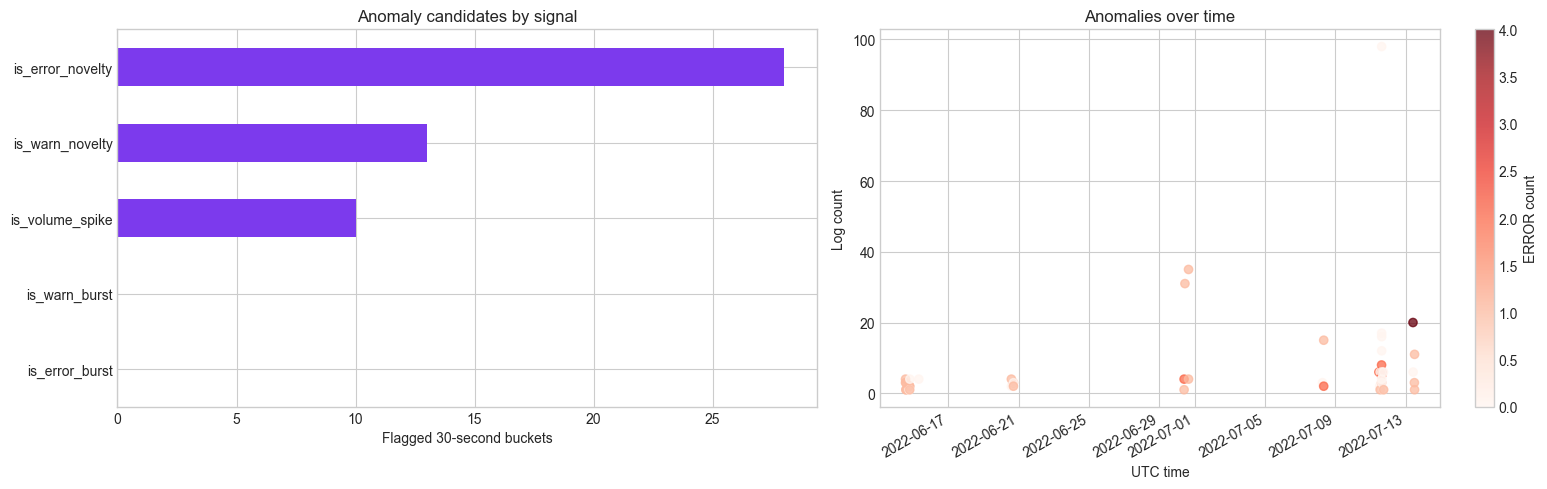

In [8]:
anomaly_flag_columns = [
    "is_volume_spike",
    "is_error_novelty",
    "is_warn_novelty",
    "is_error_burst",
    "is_warn_burst",
]

anomaly_type_counts = (
    detection_df[anomaly_flag_columns]
    .sum()
    .sort_values()
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5),
)

anomaly_type_counts.plot.barh(
    ax=axes[0],
    color="#7c3aed",
)

axes[0].set_title(
    "Anomaly candidates by signal"
)

axes[0].set_xlabel(
    "Flagged 30-second buckets"
)

scatter = axes[1].scatter(
    anomaly_candidates_df["time_window"],
    anomaly_candidates_df["log_count"],
    c=anomaly_candidates_df["error_count"],
    cmap="Reds",
    alpha=0.75,
)

axes[1].set_title(
    "Anomalies over time"
)

axes[1].set_xlabel("UTC time")
axes[1].set_ylabel("Log count")

# Xoay nhãn thời gian trên biểu đồ bên phải
axes[1].tick_params(
    axis="x",
    labelrotation=30,
)

# Căn nhãn sang phải để dễ đọc
for label in axes[1].get_xticklabels():
    label.set_horizontalalignment("right")

figure.colorbar(
    scatter,
    ax=axes[1],
    label="ERROR count",
)

plt.tight_layout()
plt.show()

## 6 - Truy ngược template đóng góp vào anomaly

In [9]:
anomaly_keys_df = (
    anomaly_candidates_df[
        [
            "time_window",
            "service_key",
            "analysis_group",
        ]
    ]
    .drop_duplicates()
)

anomaly_logs_df = (
    clustered_logs_df
    .merge(
        anomaly_keys_df,
        on=[
            "time_window",
            "service_key",
            "analysis_group",
        ],
        how="inner",
        validate="many_to_many",
    )
)

anomaly_template_contributors_df = (
    anomaly_logs_df
    .groupby(
        [
            "time_window",
            "service_key",
            "analysis_group",
            "EventId",
            "EventTemplate",
            "Level",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        occurrence_count=("LineId", "size"),
        unique_reporter_count=(
            "LoggingReporter",
            "nunique",
        ),
        first_log_time=("timestamp", "min"),
        last_log_time=("timestamp", "max"),
        representative_content=("Content", "first"),
    )
    .sort_values(
        [
            "time_window",
            "service_key",
            "analysis_group",
            "occurrence_count",
        ],
        ascending=[True, True, True, False],
    )
    .reset_index(drop=True)
)

display(
    anomaly_template_contributors_df.head(100)
)

,time_window,service_key,analysis_group,EventId,EventTemplate,Level,occurrence_count,unique_reporter_count,first_log_time,last_log_time,representative_content
0,2022-06-14 13:42:30+00:00,train-ticket/ts-auth-service,semantic_cluster_21,413a7bc4,<*> user <*> userName: <*>,ERROR,1,1,2022-06-14 13:42:59.616000+00:00,2022-06-14 13:42:59.616000+00:00,"Add user error, userName: test"
1,2022-06-14 13:42:30+00:00,train-ticket/ts-auth-service,semantic_cluster_21,7e5a973f,"Add user, userName: <*>",INFO,1,1,2022-06-14 13:42:59.601000+00:00,2022-06-14 13:42:59.601000+00:00,"Add user, userName: test"
2,2022-06-14 13:42:30+00:00,train-ticket/ts-auth-service,semantic_cluster_21,f4943eed,"Register user,User name: <*>",INFO,1,1,2022-06-14 13:42:59.610000+00:00,2022-06-14 13:42:59.610000+00:00,"Register user,User name: test"
3,2022-06-14 13:42:30+00:00,train-ticket/ts-auth-service,semantic_cluster_21,f557c46f,Save User Name <*>,INFO,1,1,2022-06-14 13:42:59.610000+00:00,2022-06-14 13:42:59.610000+00:00,Save User Name id���test
4,2022-06-14 13:42:30+00:00,train-ticket/ts-auth-service,semantic_cluster_28,183323ec,USER TOKEN: <*>,INFO,1,1,2022-06-14 13:42:33.801000+00:00,2022-06-14 13:42:33.801000+00:00,USER TOKEN: eyJhbGciOiJIUzI1NiJ9.eyJzdWIiOiJhZ...
...,...,...,...,...,...,...,...,...,...,...,...
95,2022-07-11 14:59:00+00:00,train-ticket/ts-auth-service,semantic_cluster_34,725cfd6e,[SeatService <*> The request seat type is <*> ...,INFO,2,2,2022-07-11 14:59:10.963000+00:00,2022-07-11 14:59:12.776000+00:00,[SeatService getLeftTicketOfInterval] The requ...
96,2022-07-11 14:59:00+00:00,train-ticket/ts-auth-service,semantic_cluster_34,5788ea86,[Travel Service] Query TripResponse,INFO,1,1,2022-07-11 14:59:04.955000+00:00,2022-07-11 14:59:04.955000+00:00,[Travel Service] Query TripResponse
97,2022-07-11 14:59:00+00:00,train-ticket/ts-auth-service,semantic_cluster_36,f779693f,"Routes Response is : Response(status=1, msg=Su...",INFO,5,3,2022-07-11 14:59:06.263000+00:00,2022-07-11 14:59:12.464000+00:00,"Routes Response is : Response(status=1, msg=Su..."
98,2022-07-11 14:59:00+00:00,train-ticket/ts-auth-service,semantic_cluster_36,83833b8d,"Response Resutl to String Response(status=1, m...",INFO,1,1,2022-07-11 14:59:08.856000+00:00,2022-07-11 14:59:08.856000+00:00,"Response Resutl to String Response(status=1, m..."


In [10]:
anomaly_number = 0

selected_anomaly = anomaly_candidates_df.iloc[
    anomaly_number
]

display(
    anomaly_template_contributors_df.loc[
        anomaly_template_contributors_df[
            "time_window"
        ].eq(selected_anomaly["time_window"])
        & anomaly_template_contributors_df[
            "service_key"
        ].eq(selected_anomaly["service_key"])
        & anomaly_template_contributors_df[
            "analysis_group"
        ].eq(selected_anomaly["analysis_group"])
    ]
)

,time_window,service_key,analysis_group,EventId,EventTemplate,Level,occurrence_count,unique_reporter_count,first_log_time,last_log_time,representative_content
0,2022-06-14 13:42:30+00:00,train-ticket/ts-auth-service,semantic_cluster_21,413a7bc4,<*> user <*> userName: <*>,ERROR,1,1,2022-06-14 13:42:59.616000+00:00,2022-06-14 13:42:59.616000+00:00,"Add user error, userName: test"
1,2022-06-14 13:42:30+00:00,train-ticket/ts-auth-service,semantic_cluster_21,7e5a973f,"Add user, userName: <*>",INFO,1,1,2022-06-14 13:42:59.601000+00:00,2022-06-14 13:42:59.601000+00:00,"Add user, userName: test"
2,2022-06-14 13:42:30+00:00,train-ticket/ts-auth-service,semantic_cluster_21,f4943eed,"Register user,User name: <*>",INFO,1,1,2022-06-14 13:42:59.610000+00:00,2022-06-14 13:42:59.610000+00:00,"Register user,User name: test"
3,2022-06-14 13:42:30+00:00,train-ticket/ts-auth-service,semantic_cluster_21,f557c46f,Save User Name <*>,INFO,1,1,2022-06-14 13:42:59.610000+00:00,2022-06-14 13:42:59.610000+00:00,Save User Name id���test


In [11]:
display(
    anomaly_logs_df.loc[
        anomaly_logs_df["time_window"].eq(
            selected_anomaly["time_window"]
        )
        & anomaly_logs_df["service_key"].eq(
            selected_anomaly["service_key"]
        )
        & anomaly_logs_df["analysis_group"].eq(
            selected_anomaly["analysis_group"]
        ),
        [
            "LineId",
            "timestamp",
            "Level",
            "EventId",
            "EventTemplate",
            "LoggingReporter",
            "Content",
        ],
    ].sort_values("timestamp")
)

,LineId,timestamp,Level,EventId,EventTemplate,LoggingReporter,Content
2,146238,2022-06-14 13:42:59.601000+00:00,INFO,7e5a973f,"Add user, userName: <*>",[io-16115-exec-6] a.controller.AdminUserContr...,"Add user, userName: test"
3,146236,2022-06-14 13:42:59.610000+00:00,INFO,f4943eed,"Register user,User name: <*>",[io-12342-exec-8] user.controller.UserControl...,"Register user,User name: test"
4,146237,2022-06-14 13:42:59.610000+00:00,INFO,f557c46f,Save User Name <*>,[io-12342-exec-8] user.service.impl.UserServi...,Save User Name id���test
6,146234,2022-06-14 13:42:59.616000+00:00,ERROR,413a7bc4,<*> user <*> userName: <*>,[io-16115-exec-6] adminuser.service.AdminUser...,"Add user error, userName: test"


In [12]:
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LOG_ANOMALY_BUCKETS_PATH = (
    OUTPUT_DIR / "log_anomaly_candidates.csv"
)

LOG_ANOMALY_EVIDENCE_PATH = (
    OUTPUT_DIR / "log_anomaly_template_contributors.csv"
)

anomaly_candidates_df.to_csv(
    LOG_ANOMALY_BUCKETS_PATH,
    index=False,
)

anomaly_template_contributors_df.to_csv(
    LOG_ANOMALY_EVIDENCE_PATH,
    index=False,
)

print(
    "Exported anomaly buckets:",
    LOG_ANOMALY_BUCKETS_PATH.resolve(),
)
print("Rows:", len(anomaly_candidates_df))

print(
    "Exported template evidence:",
    LOG_ANOMALY_EVIDENCE_PATH.resolve(),
)
print("Rows:", len(anomaly_template_contributors_df))

Exported anomaly buckets: E:\AIO\Project\aiops-trainticket-pipeline\data\processed\log_anomaly_candidates.csv
Rows: 51
Exported template evidence: E:\AIO\Project\aiops-trainticket-pipeline\data\processed\log_anomaly_template_contributors.csv
Rows: 136
